# Stochastic methods

In [1]:
using Logging

global_logger(ConsoleLogger(stderr, Logging.Info; show_limited=false))

Base.CoreLogging.SimpleLogger(VSCodeServer.IJuliaCore.IJuliaStdio{Base.PipeEndpoint, typeof(VSCodeServer.io_send_callback)}(IOContext(Base.PipeEndpoint(Base.Libc.WindowsRawSocket(0x0000000000000344) open, 0 bytes waiting)), VSCodeServer.io_send_callback), Info, Dict{Any, Int64}())

In [2]:
using Plots, Distributions, LinearAlgebra
import Random: seed!

## noisy descent

In [3]:
abstract type DescentMethod end

struct GradientDescent <: DescentMethod
    α
end

init!(M::GradientDescent, f, ∇f, x) = M

function step!(M::GradientDescent, f, ∇f, x)
    α, g = M.α, ∇f(x)
    return x - α * g

end

step! (generic function with 1 method)

In [4]:


mutable struct NoisyDescent <: DescentMethod
    submethod
    σ
    k
end

function init!(M::NoisyDescent, f, ∇f, x)
    init!(M.submethod, f, ∇f, x)
    M.k = 1
    return M
end

function step!(M::NoisyDescent, f, ∇f, x)
    x = step!(M.submethod, f, ∇f, x)
    σ = M.σ/M.k 
    x += σ .* randn(length(x))
    M.k += 1
    return x

end

step! (generic function with 2 methods)

In [5]:
f(x) = sum(x.^2)
∇f(x) = 2*x

∇f (generic function with 1 method)

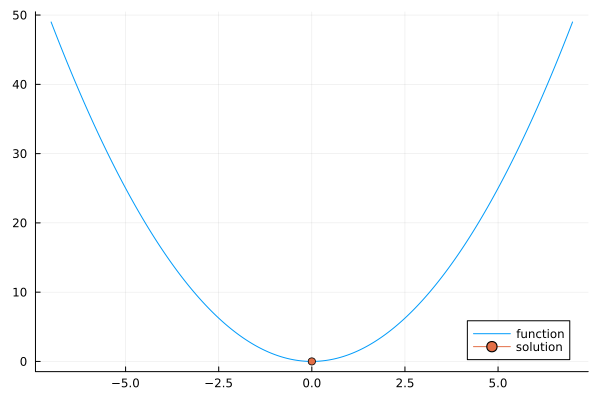

In [6]:
limits=range(-7,7,length=1000)
plot(limits, f.(limits), label="function")
plot!([0],[f(0)], mark=:circle, label="solution")

In [7]:
M=NoisyDescent(GradientDescent(0.1), 0.5,1)

NoisyDescent(GradientDescent(0.1), 0.5, 1)

In [8]:
M.k, M.σ

(1, 0.5)

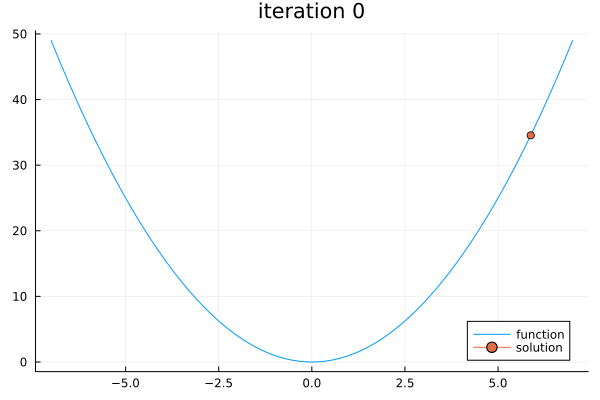

0 [5.877366606877263] 0.12263339312273658 2
1 [5.248905812505088] 0.6284607943721756 3
2 [5.3777546129713105] 0.1288488004662227 4
3 [5.488811050382716] 0.11105643741140536 5
4 [5.255213771353187] 0.23359727902952887 6
5 [5.031597223603732] 0.22361654774945539 7
6 [4.721295082032657] 0.31030214157107494 8
7 [4.473675928359887] 0.24761915367276988 9
8 [4.336257429188917] 0.1374184991709697 10
9 [4.137627730289885] 0.19862969889903237 11
10 [3.9114906878230924] 0.22613704246679234 12
11 [3.80896121803454] 0.1025294697885526 13
12 [3.6617216487803383] 0.14723956925420145 14
13 [3.447835695326416] 0.21388595345392236 15
14 [3.2889184159048055] 0.1589172794216105 16
15 [3.153287676421552] 0.13563073948325366 17
16 [3.04839819619908] 0.10488948022247202 18
17 [2.9148434581709783] 0.13355473802810147 19
18 [2.811190142577628] 0.10365331559335056 20
19 [2.720808462065005] 0.09038168051262296 21
20 [2.6152626390541966] 0.10554582301080817 22
21 [2.5019216305533876] 0.11334100850080908 23
22 [2.

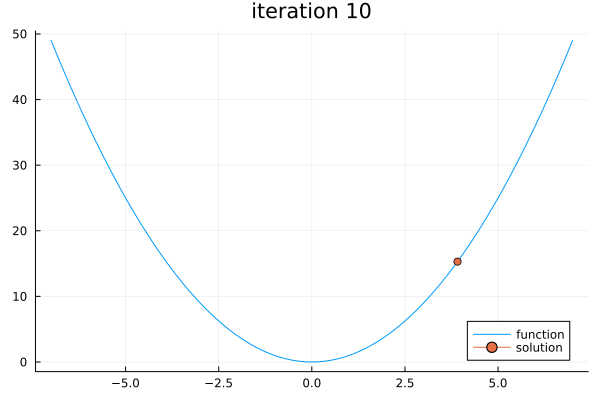

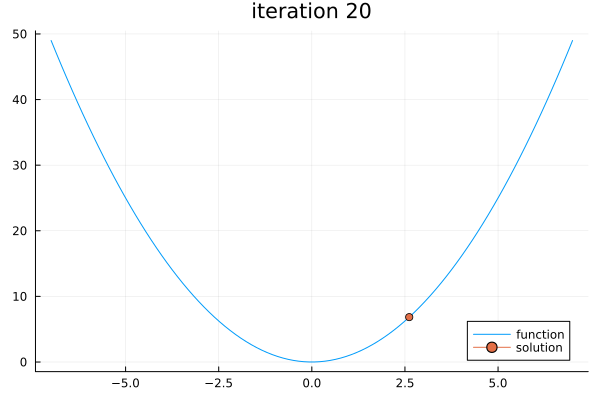

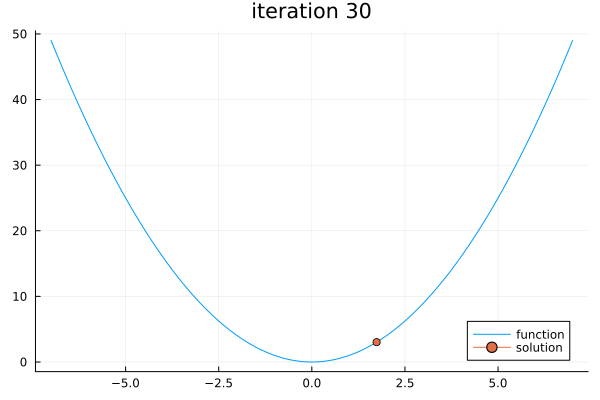

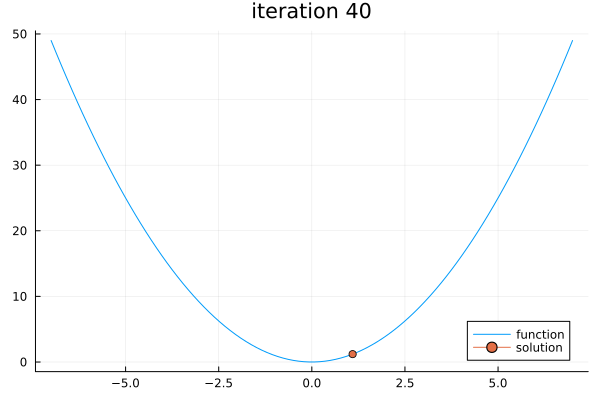

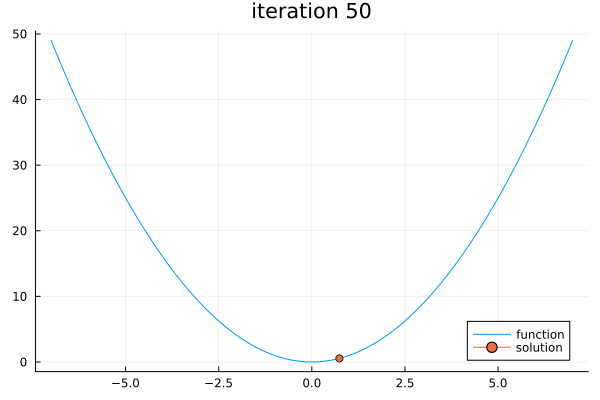

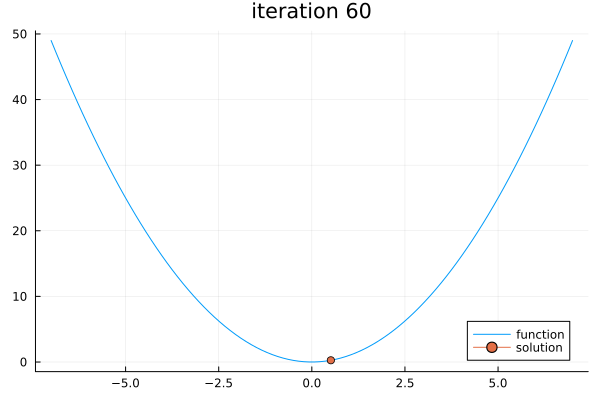

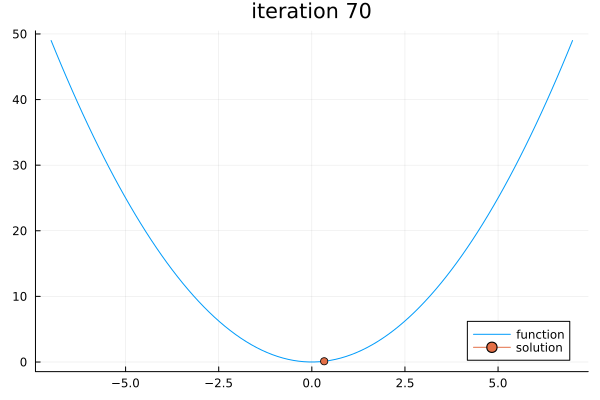

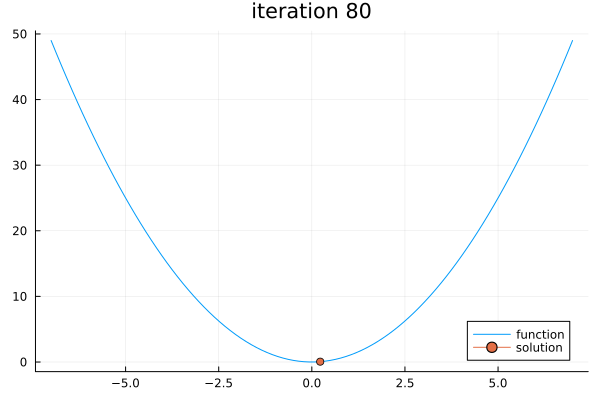

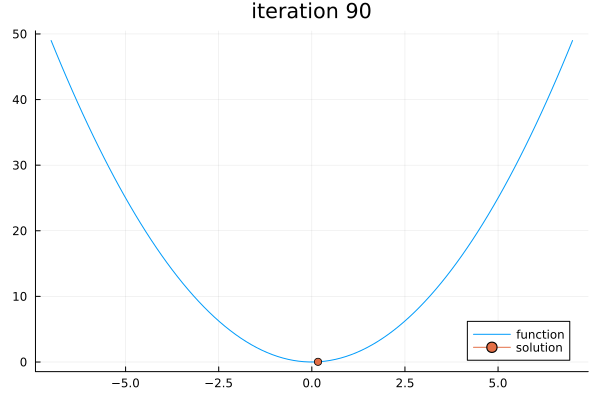

In [13]:
x = [6]
difference =1
M=NoisyDescent(GradientDescent(0.02), 0.5,1)
init!(M, f, ∇f, x)
iterations = 0
while (difference > 1e-6) & (iterations < 100)
    x_old=x
    x=step!(M, f, ∇f, x)
    difference=norm(x-x_old)
    println(iterations," ", x," ", difference, " ", M.k)
      
    if iterations % 10 == 0
        limits=range(-7,7,length=100)
        p=plot(limits, f.(limits), label="function")
        plot!(x,[f(x)], mark=:circle, label="solution")
        plot!(title="iteration $iterations")
        display(p)
    end
    iterations+=1 


end


## simulated annealing

In [14]:
function ackley(x, a=20, b=0.2, c=2π)
    d = length(x)
    return -a*exp(-b*sqrt(sum(x.^2)/d)) -
              exp(sum(cos.(c*xi) for xi in x)/d) + a + ℯ
end

ackley (generic function with 4 methods)

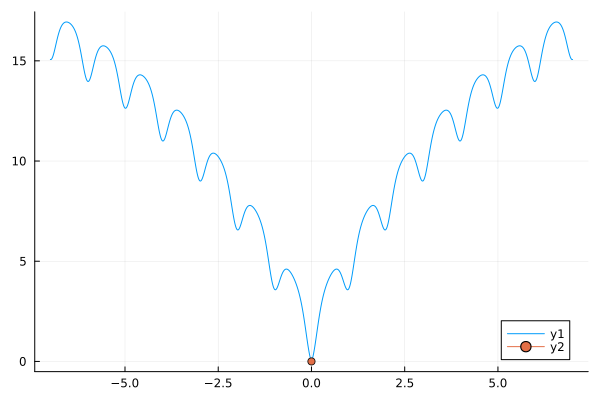

In [15]:
limits=range(-7,7,length=1000)
plot(limits, ackley.(limits))
plot!([0],[ackley(0)], mark=:circle)

In [25]:
function simulated_annealing(f, x, T, t_init, k_max)
    y = f(x)
    x_best, y_best = x, y
    t=t_init
    γ=0.5
    for k in 1 : k_max
        x′ = x + rand(T)
        y′ = f(x′)
        Δy = y′ - y
        if Δy ≤ 0 || rand() < exp(-Δy/t)
            x, y = x′, y′
        end
        if y′ < y_best
            x_best, y_best = x′, y′
        end
    # t=t/k #fast annealing
    t=γ*t # exponential annealing
    println(k, '\t', x_best,'\t', y_best, '\t', t,'\t', exp(-Δy/t)) 
    end
    return x_best, y_best
end

simulated_annealing (generic function with 1 method)

In [26]:
fobj = x-> ackley(x)
x=5
T=Normal()

Normal{Float64}(μ=0.0, σ=1.0)

In [28]:
simulated_annealing(fobj, x, T, 5, 100)

1	5	12.642411176571153	2.5	0.5124164770304402
2	5	12.642411176571153	1.25	0.344082236483884
3	4.0008545485972276	11.01499566278716	0.625	114.16148753176357
4	4.0008545485972276	11.01499566278716	0.3125	0.0016260138051545972
5	4.0008545485972276	11.01499566278716	0.15625	3.5096765083928406e-8
6	2.4844106155762704	10.180140798331864	0.078125	43745.42281879009
7	2.4844106155762704	10.180140798331864	0.0390625	1.953159080152192e-26
8	1.756499996732249	7.601155701804547	0.01953125	2.2181791165206157e57
9	0.653294492226232	4.602932099398018	0.009765625	2.169028818340576e133
10	0.653294492226232	4.602932099398018	0.0048828125	1.4448658860409178e-279
11	-0.2759180564460312	2.9417228651021046	0.00244140625	3.217806558294472e295
12	-0.2759180564460312	2.9417228651021046	0.001220703125	8.858206040834186e-152
13	-0.2759180564460312	2.9417228651021046	0.0006103515625	0.0
14	-0.2759180564460312	2.9417228651021046	0.00030517578125	0.0
15	-0.2759180564460312	2.9417228651021046	0.000152587890625	0.0
16

(0.05032765159161241, 0.33179111260760097)

In [29]:
function simulated_annealing1(f, x, T, t_init, k_max)
    y = f(x)
    x_best, y_best = x, y
    t=t_init
    γ=0.5
    for k in 1 : k_max
        x′ = x + rand(T)
        y′ = f(x′)
        Δy = y′ - y
        if Δy ≤ 0 || rand() < exp(-Δy/t)
            x, y = x′, y′
        end
        if y′ < y_best
            x_best, y_best = x′, y′
            p=plot(limits, fobj.(limits), label ="f")
            plot!([x_best], [y_best], mark=:circle, label="current solution")
            plot!(title="iteration $k")
            display(p)
        end
    # t=t/k #fast annealing
    t=γ*t # exponential annealing
    println(k, '\t', x_best,'\t', y_best)
    
    # sleep(1)
    end
    return x_best
end

simulated_annealing1 (generic function with 1 method)

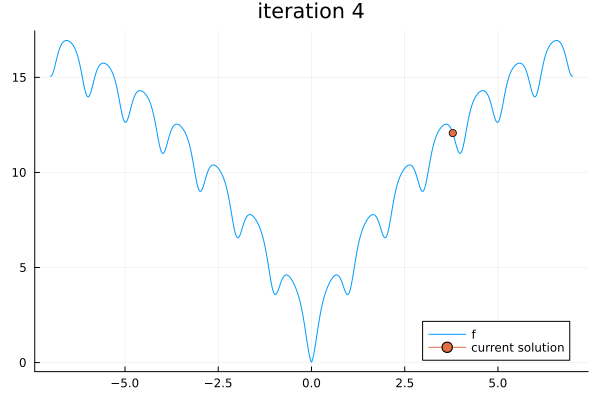

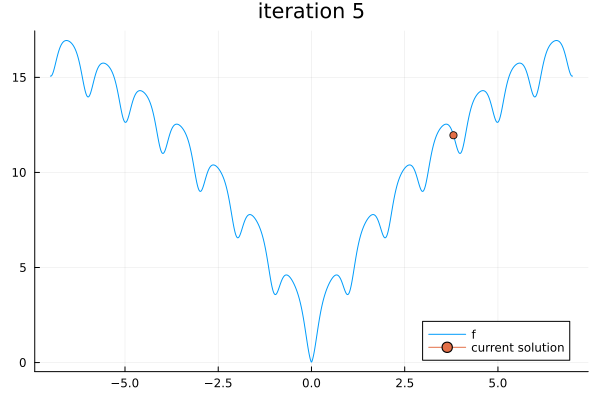

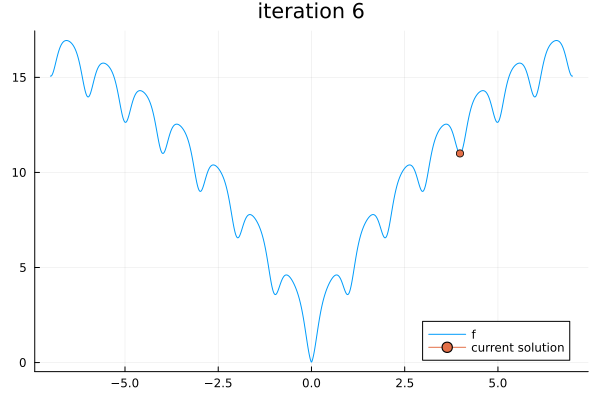

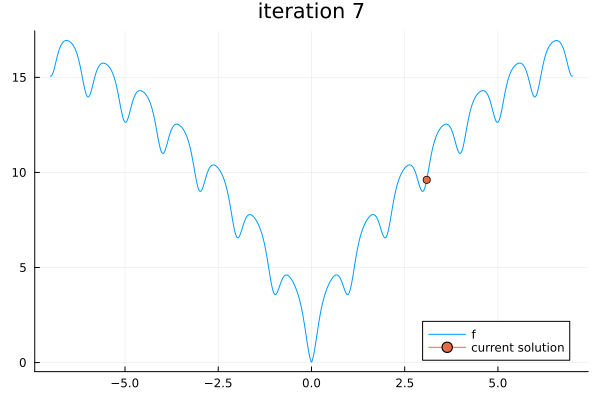

1	5	12.642411176571153
2	5	12.642411176571153
3	5	12.642411176571153
4	3.788858252424376	12.070630735893724
5	3.8074866515461627	11.955052386804184
6	3.98210985893451	10.99831001672747
7	3.089909142280183	9.610532685703603
8	3.089909142280183	9.610532685703603
9	3.089909142280183	9.610532685703603
10	1.414834247331754	7.224313843086296
11	1.414834247331754	7.224313843086296
12	-0.47904957409481197	4.174471533729548
13	-0.9641612121675538	3.5753619604602815
14	-0.9641612121675538	3.5753619604602815
15	-0.9641612121675538	3.5753619604602815
16	-0.9641612121675538	3.5753619604602815
17	-0.9641612121675538	3.5753619604602815
18	-0.9641612121675538	3.5753619604602815
19	-0.9641612121675538	3.5753619604602815
20	-0.9641612121675538	3.5753619604602815
21	-0.9641612121675538	3.5753619604602815
22	-0.9641612121675538	3.5753619604602815
23	-0.9641612121675538	3.5753619604602815
24	-0.9641612121675538	3.5753619604602815
25	-0.9715407057197686	3.5749160740644546
26	-0.9715407057197686	3.5749160740

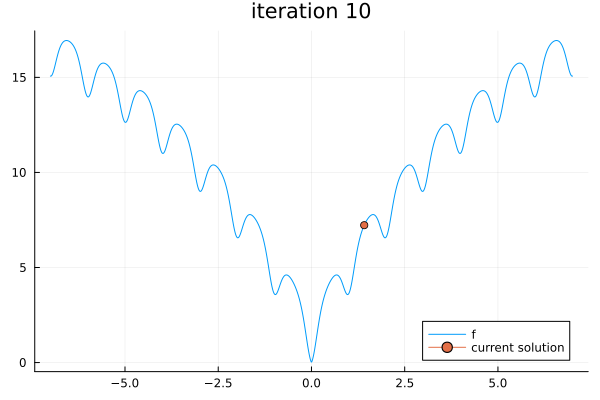

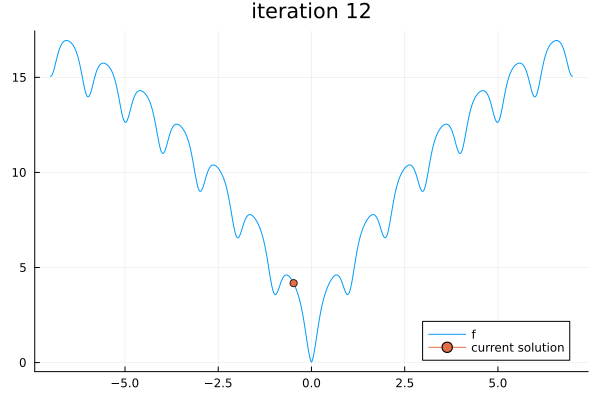

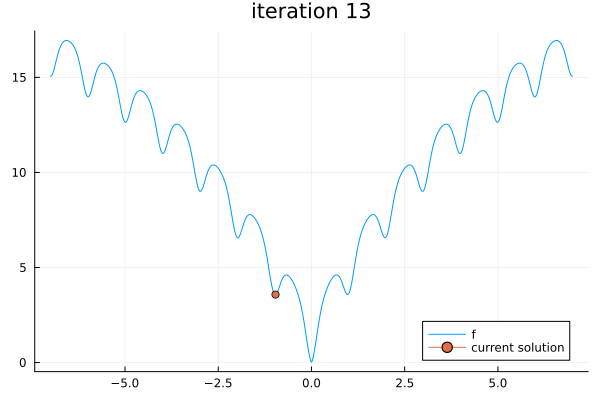

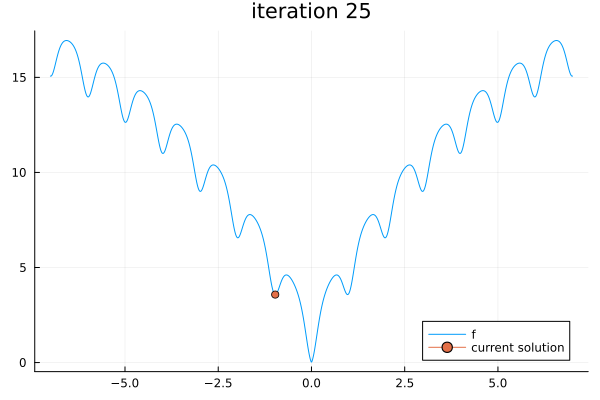

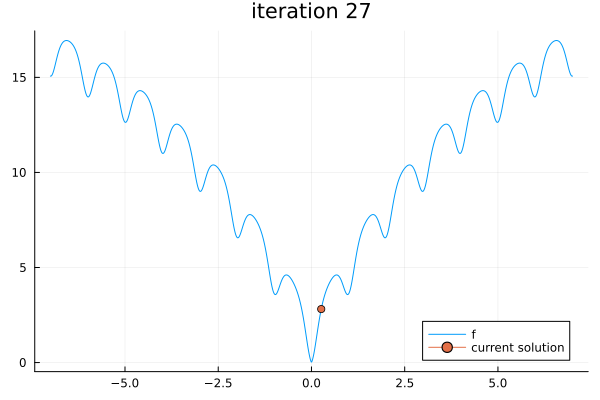

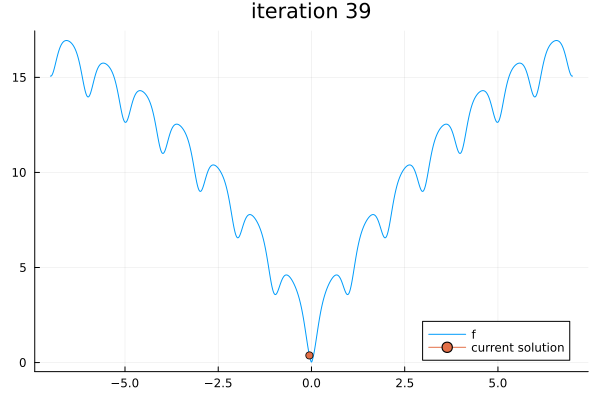

-0.05498337530946468

In [19]:
simulated_annealing1(fobj, x, T, 5, 50)

## cross - entropy method

In [30]:

function cross_entropy_method(f, P, k_max, m=100, m_elite=10)
    for k in 1:k_max
        samples = rand(P, m)
        order = sortperm([f(samples[:, i]) for i in 1:m])
        P = fit(typeof(P), samples[:, order[1:m_elite]])
        println(k, '\t', P.μ)
    end
    return P
end

cross_entropy_method (generic function with 3 methods)

In [31]:

seed!(0) # set random seed for reproducible results
f_ = x->norm(x)
μ = [0.5, 1.5]
Σ = [1.0 0.2; 0.2 2.0]
P = MvNormal(μ, Σ)
k_max = 10
P = cross_entropy_method(f_, P, k_max)
@show P.μ

1	[-0.015107219618417534, 0.26435939309868933]
2	[-0.05023723202329071, 0.07503159515494916]
3	[-6.70113718835054e-5, 0.013537636100998129]
4	[-0.0010185953781943393, 0.001687073399269581]
5	[0.00023746005911917615, 0.0013728418103874744]
6	[4.0851087658012074e-5, -8.167646213160913e-5]
7	[1.4858435798744828e-5, -1.9836098276138568e-5]
8	[4.783644112336895e-6, -4.387652413122026e-6]
9	[-6.3353794565893e-6, 1.3884707457660083e-6]
10	[-1.7329565477016673e-6, -7.042440586544702e-7]
P.μ = [-1.7329565477016673e-6, -7.042440586544702e-7]


2-element Vector{Float64}:
 -1.7329565477016673e-6
 -7.042440586544702e-7

## #To do:
1. Apply the  cross-entropy method to the Branin function (in the book). 
2. Apply simulated annealing for the function Rastringin function `rastrigin(x) = 10 + x^2 - 10*cos(2π*x)`. 
   - Try three different temperature update techniques. 
3. For both methods test at least five different parameter settings, save the results and decide if there is a particular setting that you would recommend for these functions. 
